In [2]:
import pandas as pd

cols = (
    ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv("../data/raw/cmapss/train_FD001.txt", sep=r"\s+", header=None)
df = df.iloc[:, :26]
df.columns = cols

print(df.shape)
print(df.head())
print(df["unit"].nunique(), "engines")
print(df.groupby("unit")["cycle"].max().describe())

(20631, 26)
   unit  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  \
0     1      1       -0.0007       -0.0004         100.0    518.67    641.82   
1     1      2        0.0019       -0.0003         100.0    518.67    642.15   
2     1      3       -0.0043        0.0003         100.0    518.67    642.35   
3     1      4        0.0007        0.0000         100.0    518.67    642.35   
4     1      5       -0.0019       -0.0002         100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20 

In [3]:
# RUL = how many cycles are left before this engine fails
max_cycle = df.groupby("unit")["cycle"].transform("max")
df["RUL"] = max_cycle - df["cycle"]

print(df[["unit", "cycle", "RUL"]].head(10))

   unit  cycle  RUL
0     1      1  191
1     1      2  190
2     1      3  189
3     1      4  188
4     1      5  187
5     1      6  186
6     1      7  185
7     1      8  184
8     1      9  183
9     1     10  182


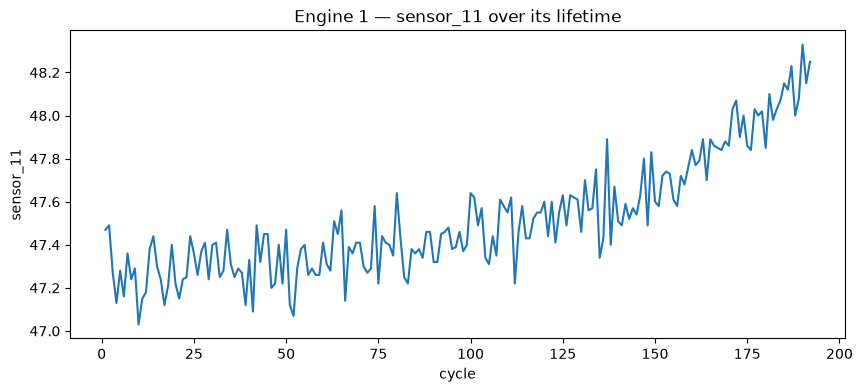

In [4]:
import matplotlib.pyplot as plt

engine_1 = df[df["unit"] == 1]

plt.figure(figsize=(10, 4))
plt.plot(engine_1["cycle"], engine_1["sensor_11"])
plt.xlabel("cycle")
plt.ylabel("sensor_11")
plt.title("Engine 1 — sensor_11 over its lifetime")
plt.show()

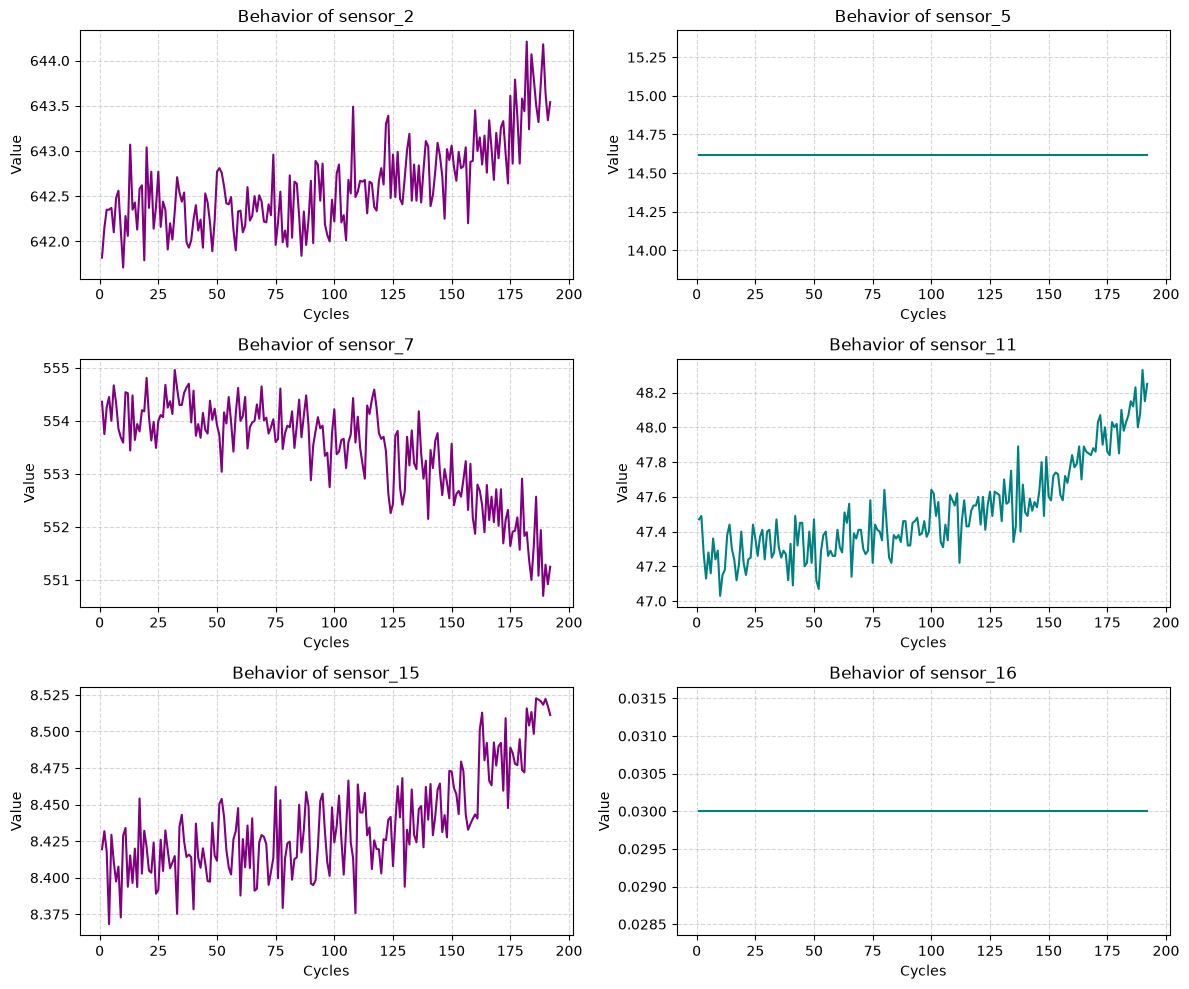

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Look at Engine 1's full history again
engine_1 = df[df["unit"] == 1]

# 2. Pick a handful of different sensors to compare
# We'll pick a mix of expected tattletales and suspected flatlines
sensors_to_check = ["sensor_2", "sensor_5", "sensor_7", "sensor_11", "sensor_15", "sensor_16"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_check):
    ax = axes[i]
    ax.plot(engine_1["cycle"], engine_1[sensor], color="purple" if i%2==0 else "teal")
    ax.set_title(f"Behavior of {sensor}")
    ax.set_xlabel("Cycles")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(df[sensor_cols].std().sort_values())

sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64


In [7]:
flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

In [8]:
df = df.drop(columns=flat_sensors)
op_setting_cols = ["op_setting_1", "op_setting_2", "op_setting_3"]

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
print(f"{len(sensor_cols)} sensors remaining:", sensor_cols)

14 sensors remaining: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [9]:
print(df["op_setting_3"].std())

0.0


In [10]:
df = df.drop(columns=["op_setting_3"])

In [11]:
window = 5

for s in sensor_cols:
    df[f"{s}_roll_mean"] = df.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f"{s}_roll_std"]  = df.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
    df[f"{s}_rate"]      = df.groupby("unit")[s].transform(lambda x: x.diff(window))

df[[f"{s}_rate", "sensor_9"]].fillna(0, inplace=False)  # just a peek, not modifying yet
print(df.shape)
print(df.columns.tolist())

(20631, 61)
['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_2_rate', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_3_rate', 'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_4_rate', 'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_7_rate', 'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_8_rate', 'sensor_9_roll_mean', 'sensor_9_roll_std', 'sensor_9_rate', 'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_11_rate', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_12_rate', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_13_rate', 'sensor_14_roll_mean', 'sensor_14_roll_std', 'sensor_14_rate', 'sensor_15_roll_mean', 'sensor_15_roll_std', 'sensor_15_rate', 'sensor_17_roll_mean', 'sensor_17_roll_std', 'sensor_17_rate', 'sensor_20_roll_m

In [12]:
# 1. Fill NaNs from the rate features
rate_cols = [c for c in df.columns if c.endswith("_rate")]
df[rate_cols] = df[rate_cols].fillna(0)

# 2. Cap RUL at 125 (standard C-MAPSS practice)
df["RUL"] = df["RUL"].clip(upper=125)

# 3. Split by unit — 80 engines train, 20 engines test
import numpy as np
units = df["unit"].unique()
np.random.seed(42)
test_units = np.random.choice(units, size=20, replace=False)

train_df = df[~df["unit"].isin(test_units)]
test_df  = df[df["unit"].isin(test_units)]

print(train_df.shape, test_df.shape)

(16561, 61) (4070, 61)


In [16]:
import sys
sys.path.append("..")

from src.turbine.evaluate import rmse, phm08_score

# Features = everything except identifiers and the target
drop_cols = ["unit", "cycle", "RUL"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train, y_train = train_df[feature_cols], train_df["RUL"]
X_test, y_test   = test_df[feature_cols], test_df["RUL"]

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

preds = model.predict(X_test)
# Get just the last row of each test engine — that's the standard evaluation point
last_cycle_test = test_df.loc[test_df.groupby("unit")["cycle"].idxmax()]

X_last = last_cycle_test[feature_cols]
y_last = last_cycle_test["RUL"]
preds_last = model.predict(X_last)

print("RMSE (final cycle only):", rmse(y_last, preds_last))
print("PHM08 score (final cycle only):", phm08_score(y_last, preds_last))

RMSE (final cycle only): 3.86462451836561
PHM08 score (final cycle only): 7.920933804631661


In [17]:
# Load the real held-out test set
test_raw = pd.read_csv("../data/raw/cmapss/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, :26]
test_raw.columns = cols

# Load the true RUL values — one per engine, in engine order
true_rul = pd.read_csv("../data/raw/cmapss/RUL_FD001.txt", header=None)[0].values

print(test_raw.shape, len(true_rul))

(13096, 26) 100


In [18]:
def engineer_features(raw_df, window=5):
    d = raw_df.copy()

    # same flat sensors dropped from training
    flat_sensors = ["sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
    d = d.drop(columns=flat_sensors + ["op_setting_3"])

    sensor_cols = [c for c in d.columns if c.startswith("sensor_")]

    for s in sensor_cols:
        d[f"{s}_roll_mean"] = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).mean())
        d[f"{s}_roll_std"]  = d.groupby("unit")[s].transform(lambda x: x.rolling(window, min_periods=1).std())
        d[f"{s}_rate"]      = d.groupby("unit")[s].transform(lambda x: x.diff(window))

    rate_cols = [c for c in d.columns if c.endswith("_rate")]
    d[rate_cols] = d[rate_cols].fillna(0)

    return d

test_featured = engineer_features(test_raw)
print(test_featured.shape)

(13096, 60)


In [19]:
# Get the last row of each test engine — the truncation point
last_rows = test_featured.loc[test_featured.groupby("unit")["cycle"].idxmax()]

# Make sure engines are in order 1, 2, 3... so predictions line up with true_rul
last_rows = last_rows.sort_values("unit")

X_real_test = last_rows[feature_cols]
preds_real = model.predict(X_real_test)

print("RMSE (real test set):", rmse(true_rul, preds_real))
print("PHM08 score (real test set):", phm08_score(true_rul, preds_real))

RMSE (real test set): 18.660624504843355
PHM08 score (real test set): 928.1066603336209
